Saved: nautilus_outer_layer_tightened_no_warning.png


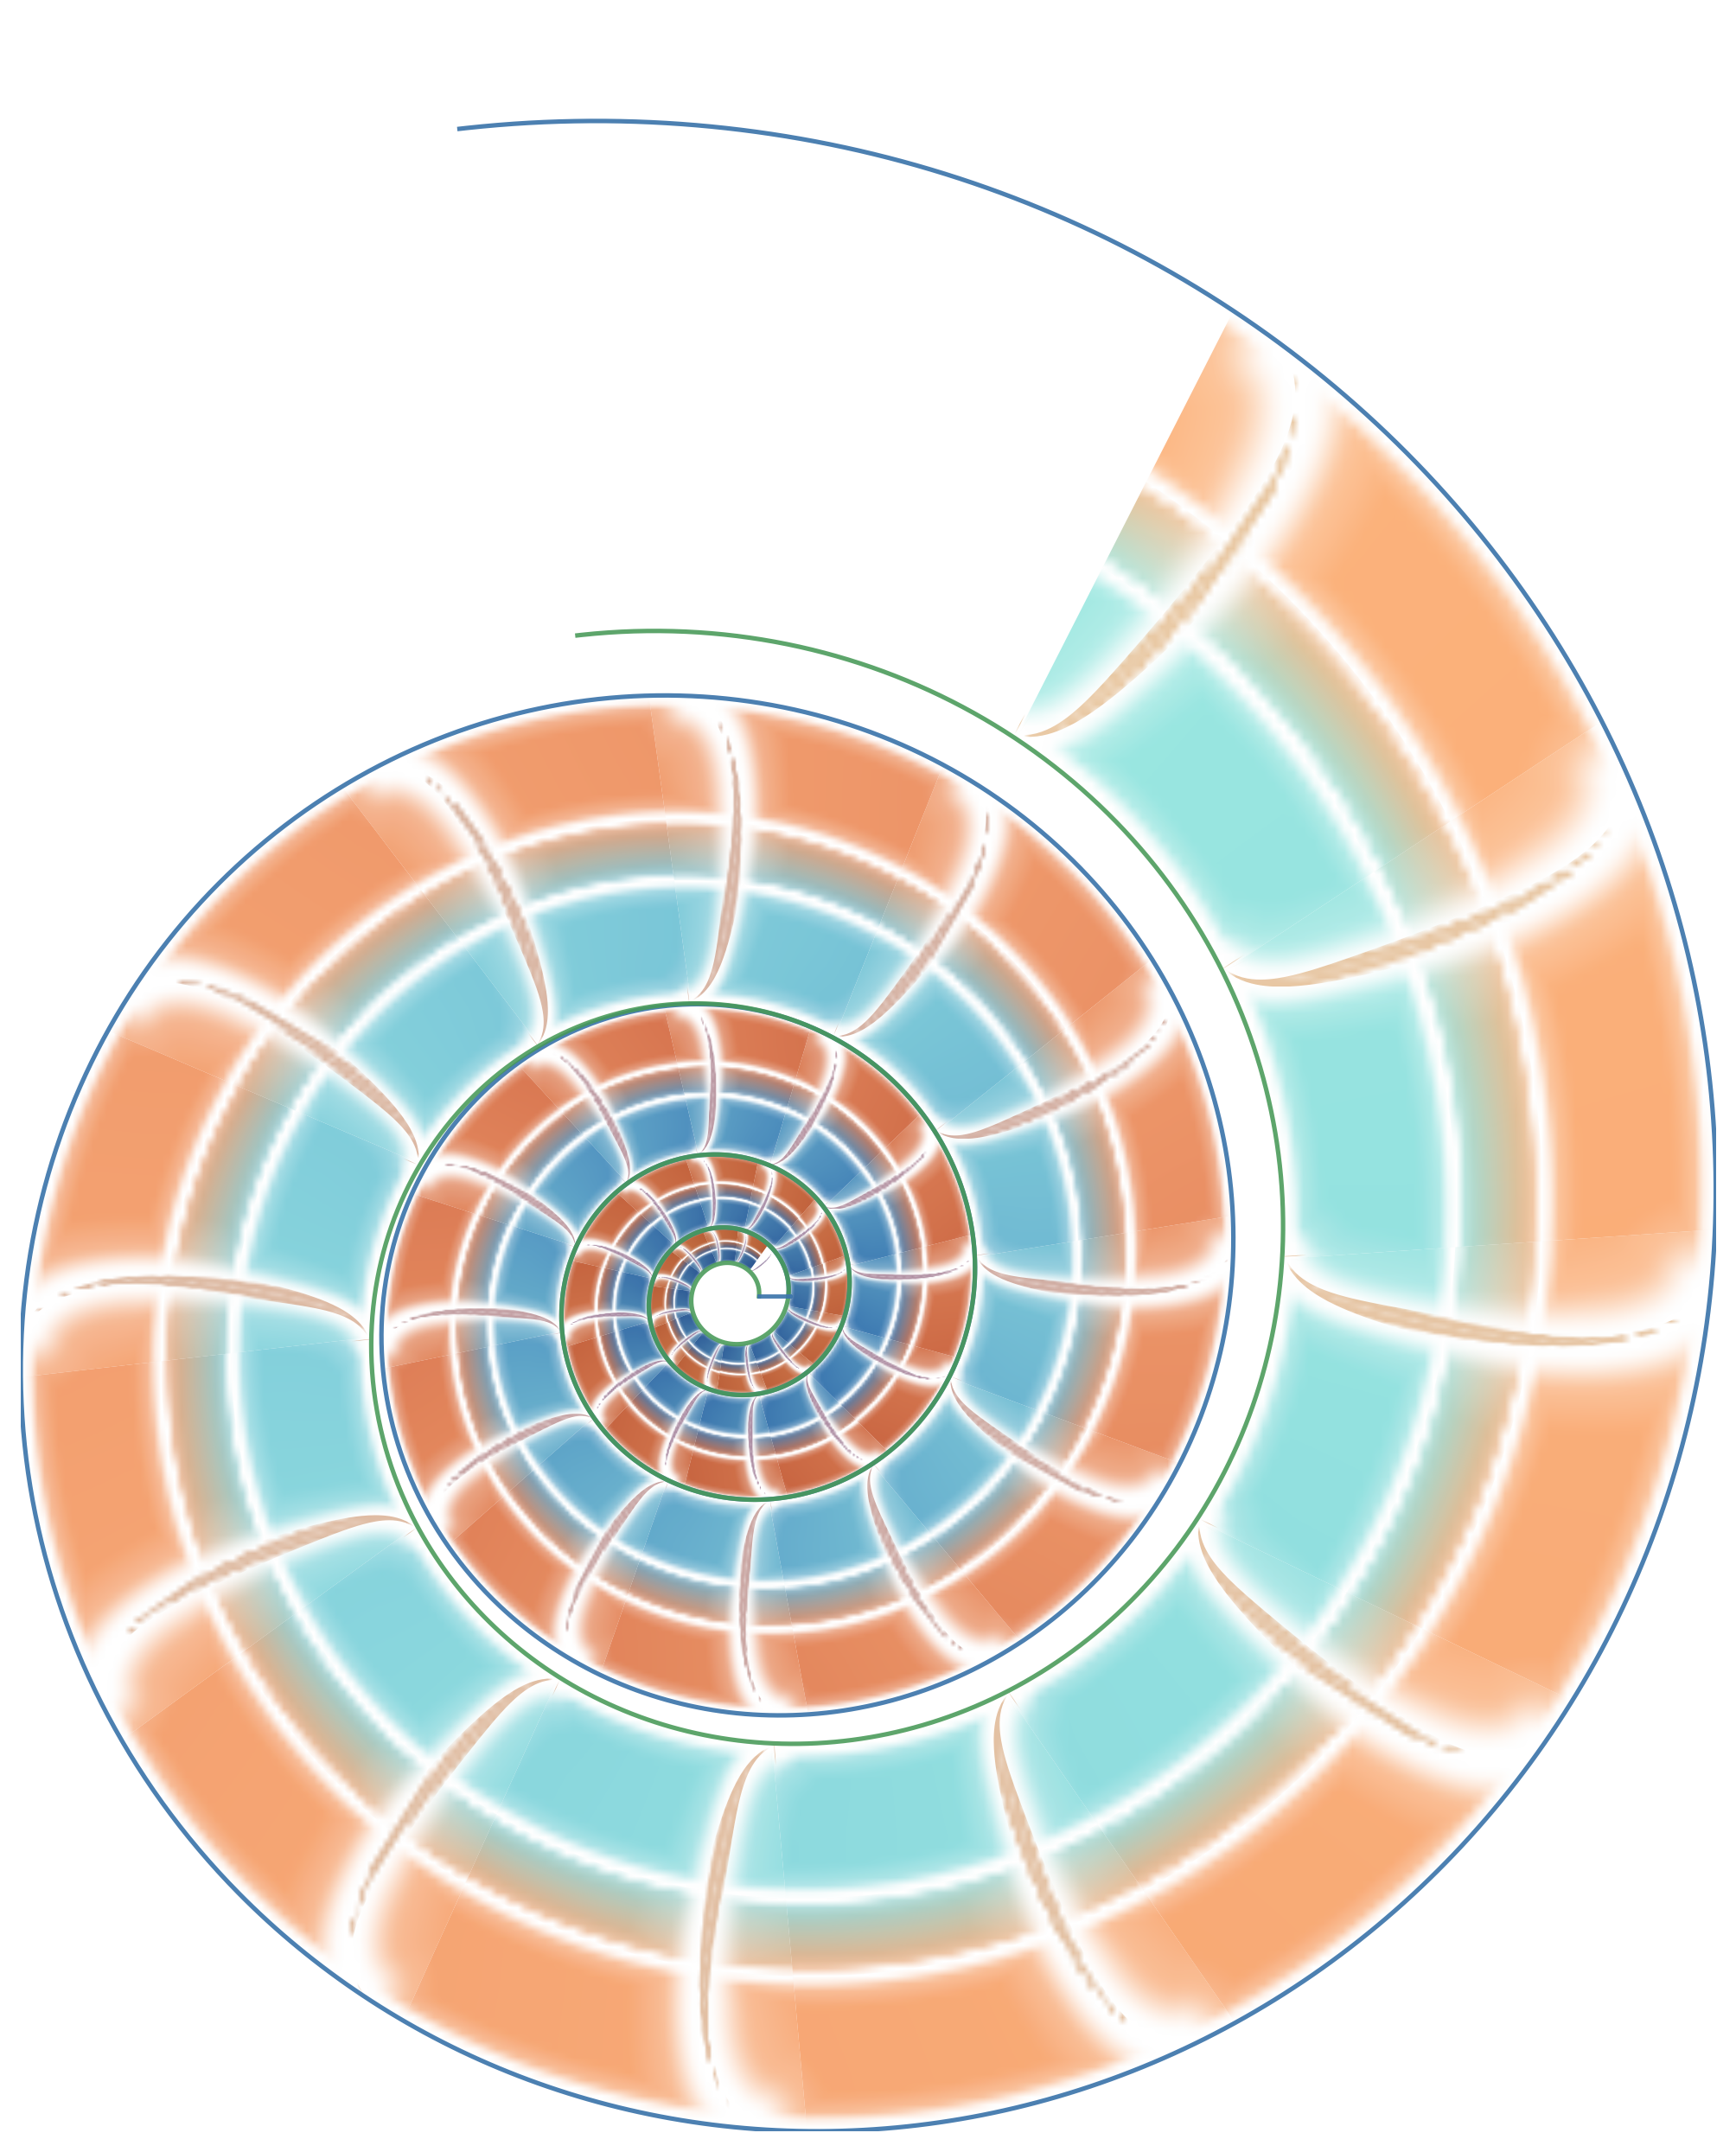

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image as IPyImage, display
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch

# ============================================================
# Nautilus shell illustration
# - extra outer chamber layer
# - tightened outermost added layer
# - sealed aperture
# - no ray-like radial segmentation
# - safe cap extent to avoid rendering warnings
# ============================================================

# -------------------- helpers --------------------
def smoothstep(x, edge0=0.0, edge1=1.0):
    t = np.clip((x - edge0) / (edge1 - edge0 + 1e-12), 0.0, 1.0)
    return t * t * (3.0 - 2.0 * t)

def tight_alpha(beta: float) -> float:
    q = np.exp(2.0 * np.pi * beta)
    return (q - 1.0) / (q + 1.0)

def lerp_color(c0, c1, t):
    c0 = np.asarray(c0, dtype=float)
    c1 = np.asarray(c1, dtype=float)
    t = np.asarray(t, dtype=float)
    if t.ndim == 0:
        return (1.0 - t) * c0 + t * c1
    return (1.0 - t)[..., None] * c0 + t[..., None] * c1

def clip_rgb(arr):
    return np.clip(arr, 0.0, 1.0)

def safe_extent_from_poly(poly, pad_frac=0.02, min_span=1e-3):
    """
    Return a non-degenerate extent for imshow clipping.
    If the polygon bbox is too thin in x or y, force a minimum span,
    then add a small padding. This avoids identical-low-high limit warnings.
    """
    poly = np.asarray(poly, dtype=float)
    xmin = float(np.min(poly[:, 0]))
    xmax = float(np.max(poly[:, 0]))
    ymin = float(np.min(poly[:, 1]))
    ymax = float(np.max(poly[:, 1]))

    dx = xmax - xmin
    dy = ymax - ymin

    if dx < min_span:
        cx = 0.5 * (xmin + xmax)
        xmin = cx - 0.5 * min_span
        xmax = cx + 0.5 * min_span
        dx = min_span

    if dy < min_span:
        cy = 0.5 * (ymin + ymax)
        ymin = cy - 0.5 * min_span
        ymax = cy + 0.5 * min_span
        dy = min_span

    padx = pad_frac * dx
    pady = pad_frac * dy
    return xmin - padx, xmax + padx, ymin - pady, ymax + pady

# -------------------- geometry --------------------
OLD_THETA_MAX = 6.35 * np.pi

def outer_layer_width_scale(theta, theta_max):
    """
    Keep original shell width unchanged up to OLD_THETA_MAX.
    Only tighten the newly added outer layer beyond OLD_THETA_MAX.
    """
    theta = np.asarray(theta, dtype=float)
    s = np.clip((theta - OLD_THETA_MAX) / max(theta_max - OLD_THETA_MAX, 1e-12), 0.0, 1.0)
    return 1.0 - 0.20 * smoothstep(s, 0.0, 1.0)

def spiral_bundle(theta, r0=0.22, beta=0.115, theta_max=None):
    rc = r0 * np.exp(beta * theta)
    alpha = tight_alpha(beta)
    width_scale = 1.0 if theta_max is None else outer_layer_width_scale(theta, theta_max)
    w = alpha * rc * width_scale
    return rc, rc - w, rc + w, alpha

def auxiliary_radii(theta, r0=0.22, beta=0.115, theta_max=None):
    rc, rin, rout, _ = spiral_bundle(theta, r0=r0, beta=beta, theta_max=theta_max)
    width = rout - rin
    return rc - 0.10 * width, rc, rc + 0.10 * width, rin, rout

def polar_to_xy(r, theta):
    return r * np.cos(theta), r * np.sin(theta)

def centerline_frame(theta, r0=0.22, beta=0.115):
    r = r0 * np.exp(beta * theta)
    dr = beta * r
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    dx = dr * np.cos(theta) - r * np.sin(theta)
    dy = dr * np.sin(theta) + r * np.cos(theta)
    nrm = np.hypot(dx, dy)
    tx, ty = dx / nrm, dy / nrm
    nx, ny = -ty, tx
    return x, y, tx, ty, nx, ny, r

def local_soft_mouth_profile(v, a, m):
    core = np.maximum(1.0 - np.abs(v) ** m, 0.0)
    return -a * core ** (1.0 / m)

def septum_curve_harmonic(
    theta0,
    r0=0.22,
    beta=0.115,
    theta_max=None,
    mouth_scale=0.44,
    m=2.35,
    harmonics=((1, 0.10, 0.20), (2, 0.055, -0.75), (3, 0.028, 1.05)),
    n=120
):
    x0, y0, tx, ty, nx, ny, _ = centerline_frame(theta0, r0=r0, beta=beta)
    _, rin, rout, _ = spiral_bundle(np.array([theta0]), r0=r0, beta=beta, theta_max=theta_max)

    half_width = 0.5 * (rout[0] - rin[0])
    a = mouth_scale * half_width

    v = np.linspace(-1.0, 1.0, n)
    psi = 0.5 * np.pi * (v + 1.0)
    u_base = local_soft_mouth_profile(v, a=a, m=m)

    pert = np.ones_like(v)
    for k, Ak, phik in harmonics:
        pert += Ak * np.cos(k * psi + phik)
    u = u_base * pert

    x = x0 + (half_width * v) * nx + u * tx
    y = y0 + (half_width * v) * ny + u * ty
    pts = np.column_stack([x, y])

    pts[0] = np.array([rin[0] * np.cos(theta0), rin[0] * np.sin(theta0)])
    pts[-1] = np.array([rout[0] * np.cos(theta0), rout[0] * np.sin(theta0)])
    return pts

def tapered_double_curve(pts, d):
    dx = np.gradient(pts[:, 0])
    dy = np.gradient(pts[:, 1])
    speed = np.hypot(dx, dy)
    nx = -dy / np.maximum(speed, 1e-12)
    ny = dx / np.maximum(speed, 1e-12)

    s = np.linspace(0.0, 1.0, len(pts))
    taper = np.sin(np.pi * s)

    c1 = np.column_stack([
        pts[:, 0] + 0.5 * d * taper * nx,
        pts[:, 1] + 0.5 * d * taper * ny
    ])
    c2 = np.column_stack([
        pts[:, 0] - 0.5 * d * taper * nx,
        pts[:, 1] - 0.5 * d * taper * ny
    ])

    c1[0] = pts[0]
    c1[-1] = pts[-1]
    c2[0] = pts[0]
    c2[-1] = pts[-1]
    return c1, c2

def aperture_cap_curve(p_out, p_in, bulge=0.82, n=120):
    mid = 0.5 * (p_out + p_in)
    gap = np.linalg.norm(p_out - p_in)
    outward = mid / max(np.linalg.norm(mid), 1e-12)
    ctrl = mid + bulge * gap * outward
    t = np.linspace(0.0, 1.0, n)
    return ((1.0 - t) ** 2)[:, None] * p_out + (2.0 * (1.0 - t) * t)[:, None] * ctrl + (t ** 2)[:, None] * p_in

# -------------------- colors --------------------
WHITE = np.array([1.0, 1.0, 1.0])

INNER_A = np.array([32, 74, 138]) / 255.0
INNER_B = np.array([70, 150, 208]) / 255.0
INNER_C = np.array([151, 231, 224]) / 255.0

OUTER_A = np.array([177, 86, 44]) / 255.0
OUTER_B = np.array([223, 103, 74]) / 255.0
OUTER_C = np.array([252, 177, 120]) / 255.0

WALL_A = np.array([115, 86, 132]) / 255.0
WALL_B = np.array([173, 116, 130]) / 255.0
WALL_C = np.array([226, 182, 132]) / 255.0

SHELL_OUT = np.array([0.24, 0.46, 0.67])
SHELL_IN = np.array([0.28, 0.60, 0.34])

# -------------------- main render --------------------
def render_nautilus(
    out_png="nautilus_outer_layer_tightened_no_warning.png",
    dpi=240,
    figsize=(10.2, 10.2),
):
    r0 = 0.22
    beta = 0.115
    theta_min = 0.95
    theta_max = OLD_THETA_MAX + 2 * np.pi  # one extra outer layer

    old_n_septa = 38
    dtheta = (OLD_THETA_MAX - theta_min) / (old_n_septa - 1)
    n_septa = int(round((theta_max - theta_min) / dtheta)) + 1

    theta_full = np.linspace(0.0, theta_max + 0.7, 4200)
    _, _, _, rin_full, rout_full = auxiliary_radii(theta_full, r0=r0, beta=beta, theta_max=theta_max)
    xin, yin = polar_to_xy(rin_full, theta_full)
    xout, yout = polar_to_xy(rout_full, theta_full)

    septa_theta = np.linspace(theta_min, theta_max, n_septa)
    base_septa = []
    double_curves = []

    for th in septa_theta:
        base = septum_curve_harmonic(th, r0=r0, beta=beta, theta_max=theta_max, n=120)
        base_septa.append(base)

        _, rin0, rout0, _ = spiral_bundle(np.array([th]), r0=r0, beta=beta, theta_max=theta_max)
        gap = 0.06 * (rout0[0] - rin0[0])
        double_curves.append(tapered_double_curve(base, gap))

    base_septa_ds = [curve[::2] for curve in base_septa]

    # aperture cap
    p_out = np.array([xout[0], yout[0]])
    p_in = np.array([xin[0], yin[0]])
    cap_curve = aperture_cap_curve(p_out, p_in, bulge=0.82, n=120)
    cap_poly = np.vstack([cap_curve, p_in, p_out])

    fig, ax = plt.subplots(figsize=figsize)

    # -------- chamber fills --------
    for i, (th0, th1) in enumerate(zip(septa_theta[:-1], septa_theta[1:])):
        tseg = np.linspace(th0, th1, 120)
        r_aux_in, _, r_aux_out, rin, rout = auxiliary_radii(tseg, r0=r0, beta=beta, theta_max=theta_max)

        x_rin, y_rin = polar_to_xy(rin, tseg)
        x_ain, y_ain = polar_to_xy(r_aux_in, tseg)
        x_aout, y_aout = polar_to_xy(r_aux_out, tseg)
        x_rout, y_rout = polar_to_xy(rout, tseg)

        poly_inner = np.column_stack([np.r_[x_rin, x_ain[::-1]], np.r_[y_rin, y_ain[::-1]]])
        poly_middle = np.column_stack([np.r_[x_ain, x_aout[::-1]], np.r_[y_ain, y_aout[::-1]]])
        poly_outer = np.column_stack([np.r_[x_aout, x_rout[::-1]], np.r_[y_aout, y_rout[::-1]]])

        xmin = min(poly_inner[:, 0].min(), poly_middle[:, 0].min(), poly_outer[:, 0].min())
        xmax = max(poly_inner[:, 0].max(), poly_middle[:, 0].max(), poly_outer[:, 0].max())
        ymin = min(poly_inner[:, 1].min(), poly_middle[:, 1].min(), poly_outer[:, 1].min())
        ymax = max(poly_inner[:, 1].max(), poly_middle[:, 1].max(), poly_outer[:, 1].max())

        ngrid = 58
        xs = np.linspace(xmin, xmax, ngrid)
        ys = np.linspace(ymin, ymax, ngrid)
        X, Y = np.meshgrid(xs, ys)
        P = np.stack([X.ravel(), Y.ravel()], axis=1)
        R = np.hypot(X, Y)

        theta_raw = np.arctan2(Y, X)
        theta_mid = 0.5 * (th0 + th1)
        theta_adj = theta_raw + 2 * np.pi * np.round((theta_mid - theta_raw) / (2 * np.pi))
        tau = np.clip((theta_adj - theta_min) / (theta_max - theta_min + 1e-12), 0.0, 1.0)

        left_curve = base_septa_ds[i]
        right_curve = base_septa_ds[i + 1]
        dL = np.min(((P[:, None, :] - left_curve[None, :, :]) ** 2).sum(axis=2), axis=1).reshape(X.shape)
        dR = np.min(((P[:, None, :] - right_curve[None, :, :]) ** 2).sum(axis=2), axis=1).reshape(X.shape)
        g = np.sqrt(dL) / (np.sqrt(dL) + np.sqrt(dR) + 1e-12)

        rin_t = np.interp(theta_adj, tseg, rin, left=rin[0], right=rin[-1])
        rain_t = np.interp(theta_adj, tseg, r_aux_in, left=r_aux_in[0], right=r_aux_in[-1])
        raout_t = np.interp(theta_adj, tseg, r_aux_out, left=r_aux_out[0], right=r_aux_out[-1])
        rout_t = np.interp(theta_adj, tseg, rout, left=rout[0], right=rout[-1])

        q_in = (R - rin_t) / np.maximum(rain_t - rin_t, 1e-12)
        q_mid = (R - rain_t) / np.maximum(raout_t - rain_t, 1e-12)
        q_out = (R - raout_t) / np.maximum(rout_t - raout_t, 1e-12)

        edge_rad_in = np.minimum(q_in, 1.0 - q_in)
        edge_rad_mid = np.minimum(q_mid, 1.0 - q_mid)
        edge_rad_out = np.minimum(q_out, 1.0 - q_out)
        edge_septa = np.minimum(g, 1.0 - g)

        edge_light_in = 1.0 - np.clip(np.minimum(edge_rad_in, edge_septa) / 0.22, 0.0, 1.0)
        edge_light_mid = 1.0 - np.clip(np.minimum(edge_rad_mid, edge_septa) / 0.24, 0.0, 1.0)
        edge_light_out = 1.0 - np.clip(np.minimum(edge_rad_out, edge_septa) / 0.22, 0.0, 1.0)

        alpha_g = smoothstep(g, 0.02, 0.12) * smoothstep(1 - g, 0.02, 0.12)
        alpha_in = smoothstep(q_in, 0.02, 0.10) * smoothstep(1 - q_in, 0.02, 0.10) * alpha_g
        alpha_mid = smoothstep(q_mid, 0.02, 0.10) * smoothstep(1 - q_mid, 0.02, 0.10) * alpha_g
        alpha_out = smoothstep(q_out, 0.02, 0.10) * smoothstep(1 - q_out, 0.02, 0.10) * alpha_g

        c_in_growth = lerp_color(
            lerp_color(INNER_A, INNER_B, np.clip(1.15 * tau, 0, 1)),
            INNER_C,
            np.clip((tau - 0.45) / 0.55, 0, 1),
        )
        c_out_growth = lerp_color(
            lerp_color(OUTER_A, OUTER_B, np.clip(1.10 * tau, 0, 1)),
            OUTER_C,
            np.clip((tau - 0.42) / 0.58, 0, 1),
        )

        c_in = lerp_color(c_in_growth, INNER_C, 0.24 * g)
        c_out = lerp_color(c_out_growth, OUTER_C, 0.20 * g)
        c_mid = lerp_color(c_in_growth, c_out_growth, q_mid)
        c_mid = lerp_color(c_mid, lerp_color(INNER_C, OUTER_C, 0.5), 0.18 * g)

        c_in = lerp_color(c_in, WHITE, 0.48 * edge_light_in)
        c_mid = lerp_color(c_mid, WHITE, 0.42 * edge_light_mid)
        c_out = lerp_color(c_out, WHITE, 0.48 * edge_light_out)

        c_in = clip_rgb(c_in)
        c_mid = clip_rgb(c_mid)
        c_out = clip_rgb(c_out)

        rgba_in = np.zeros((ngrid, ngrid, 4))
        rgba_in[..., :3] = c_in
        rgba_in[..., 3] = 0.97 * alpha_in

        rgba_mid = np.zeros((ngrid, ngrid, 4))
        rgba_mid[..., :3] = c_mid
        rgba_mid[..., 3] = 0.94 * alpha_mid

        rgba_out = np.zeros((ngrid, ngrid, 4))
        rgba_out[..., :3] = c_out
        rgba_out[..., 3] = 0.97 * alpha_out

        patch_in = PathPatch(MplPath(poly_inner), facecolor="none", edgecolor="none")
        patch_mid = PathPatch(MplPath(poly_middle), facecolor="none", edgecolor="none")
        patch_out = PathPatch(MplPath(poly_outer), facecolor="none", edgecolor="none")
        ax.add_patch(patch_in)
        ax.add_patch(patch_mid)
        ax.add_patch(patch_out)

        ax.imshow(rgba_in, extent=[xmin, xmax, ymin, ymax], origin="lower",
                  interpolation="bilinear", clip_path=patch_in, clip_on=True, zorder=1)
        ax.imshow(rgba_mid, extent=[xmin, xmax, ymin, ymax], origin="lower",
                  interpolation="bilinear", clip_path=patch_mid, clip_on=True, zorder=1.5)
        ax.imshow(rgba_out, extent=[xmin, xmax, ymin, ymax], origin="lower",
                  interpolation="bilinear", clip_path=patch_out, clip_on=True, zorder=1)

    # -------- septa fills --------
    for i, ((c1, c2), base) in enumerate(zip(double_curves, base_septa_ds)):
        poly_wall = np.vstack([c1, c2[::-1]])
        xmin = poly_wall[:, 0].min()
        xmax = poly_wall[:, 0].max()
        ymin = poly_wall[:, 1].min()
        ymax = poly_wall[:, 1].max()

        ngrid = 44
        xs = np.linspace(xmin, xmax, ngrid)
        ys = np.linspace(ymin, ymax, ngrid)
        X, Y = np.meshgrid(xs, ys)
        P = np.stack([X.ravel(), Y.ravel()], axis=1)

        dist2 = ((P[:, None, :] - base[None, :, :]) ** 2).sum(axis=2)
        idx = np.argmin(dist2, axis=1)
        dmin = np.sqrt(np.min(dist2, axis=1)).reshape(X.shape)
        local_half_width = 0.5 * np.hypot(c1[:, 0] - c2[:, 0], c1[:, 1] - c2[:, 1])
        hw = local_half_width[np.clip(idx, 0, len(local_half_width) - 1)].reshape(X.shape)

        q = dmin / np.maximum(hw, 1e-12)
        tau_wall = np.clip((septa_theta[i] - theta_min) / (theta_max - theta_min + 1e-12), 0.0, 1.0)
        edge_light = 1.0 - np.clip(q / 0.35, 0.0, 1.0)
        alpha = 0.74 * smoothstep(1 - q, 0.02, 0.36)

        c_wall_growth = lerp_color(
            lerp_color(WALL_A, WALL_B, np.clip(1.20 * tau_wall, 0, 1)),
            WALL_C,
            np.clip((tau_wall - 0.45) / 0.55, 0, 1),
        )
        c_wall = lerp_color(c_wall_growth, WHITE, 0.40 * edge_light)
        c_wall = clip_rgb(c_wall)

        rgba = np.zeros((ngrid, ngrid, 4))
        rgba[..., :3] = c_wall
        rgba[..., 3] = alpha

        patch_wall = PathPatch(MplPath(poly_wall), facecolor="none", edgecolor="none")
        ax.add_patch(patch_wall)
        ax.imshow(rgba, extent=[xmin, xmax, ymin, ymax], origin="lower",
                  interpolation="bilinear", clip_path=patch_wall, clip_on=True, zorder=2)

    # -------- cap fill with safe extent --------
    cap_xmin, cap_xmax, cap_ymin, cap_ymax = safe_extent_from_poly(cap_poly, pad_frac=0.02, min_span=1e-3)

    ngrid = 60
    xs = np.linspace(cap_xmin, cap_xmax, ngrid)
    ys = np.linspace(cap_ymin, cap_ymax, ngrid)
    X, Y = np.meshgrid(xs, ys)
    P = np.stack([X.ravel(), Y.ravel()], axis=1)

    seg = p_in - p_out
    seg_len2 = max(np.dot(seg, seg), 1e-12)
    proj = np.clip(((P - p_out) @ seg) / seg_len2, 0.0, 1.0).reshape(X.shape)

    cap_in_col = lerp_color(INNER_A, INNER_B, 0.0)
    cap_out_col = lerp_color(OUTER_A, OUTER_B, 0.0)
    cap_col = lerp_color(cap_out_col, cap_in_col, proj)

    midpoint = 0.5 * (p_out + p_in)
    dist_center = np.hypot(X - midpoint[0], Y - midpoint[1])
    dist_norm = dist_center / max(dist_center.max(), 1e-12)
    cap_col = lerp_color(cap_col, WHITE, 0.22 * smoothstep(dist_norm, 0.35, 1.0))
    cap_col = clip_rgb(cap_col)

    rgba_cap = np.zeros((ngrid, ngrid, 4))
    rgba_cap[..., :3] = cap_col
    rgba_cap[..., 3] = 0.90

    patch_cap = PathPatch(MplPath(cap_poly), facecolor="none", edgecolor="none")
    ax.add_patch(patch_cap)
    ax.imshow(rgba_cap, extent=[cap_xmin, cap_xmax, cap_ymin, cap_ymax], origin="lower",
              interpolation="bilinear", clip_path=patch_cap, clip_on=True, zorder=2.2)

    # shell boundaries only
    ax.plot(xout, yout, linewidth=1.55, color=SHELL_OUT, alpha=0.92, zorder=5)
    ax.plot(xin, yin, linewidth=1.55, color=SHELL_IN, alpha=0.88, zorder=5)
    ax.plot(cap_curve[:, 0], cap_curve[:, 1], linewidth=1.45, color=SHELL_OUT, alpha=0.92, zorder=5)

    ax.set_aspect("equal")
    ax.axis("off")
    fig.tight_layout(pad=0.1)
    fig.savefig(out_png, dpi=dpi, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return out_png

if __name__ == "__main__":
    output_path = render_nautilus()
    print(f"Saved: {output_path}")
    display(IPyImage(filename=output_path))